# ICE and PG performance measure

## Dependencies

In [1]:
from ONNX_Predict.LSTM_onnx import LSTM_onnx 
from ONNX_Predict.Scaler_onnx import Scaler_onnx
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

Como se observa, no es necesario importar `tensorflow` o `keras` a menos que se requiera en alguna parte adicional del proceso.

`ONNX_Predict` se encarga de gestionar el proceso de carga en memoría e interfaz de predicción de los modelos y scalers

## Reading models and scalers

### Paths

Se definen las direcciones donde se encuentran almacenados los modelos de `onnx` así como los modelos originales `ICE` y `PG`

In [2]:
ICE_folder = os.path.join('CTTC_models', 'ONNX', 'ICE')
PG_folder = os.path.join('CTTC_models', 'ONNX', 'PG')
tf_model = 'model.h5'

### Loading ICE model in memory

Para realizar la carga en memoría de los modelos, se debe crear una instancia de las clases `Scaler_onnx` para los scalers y `LSTM_onnx` para los modelos*

In [3]:
ICEscaler_in = Scaler_onnx('scaler_input.onnx', ICE_folder)
ICEscaler_out = Scaler_onnx('scaler_output.onnx', ICE_folder)
ICEscaler_inv_out = Scaler_onnx('scaler_inverse_output.onnx', ICE_folder)
ICE = LSTM_onnx('ICE_onnx.onnx', ICE_folder, tf_model)

**IMPORTANTE**

Observar que se realiza la carga en memoría de 3 scalers en lugar de 2.

Esto, debido a que, los modelos de onnx sólo pueden hacer la transformación en una dirección. Al requerir una transformación inversa para la predicción, se tuvo que generar `scaler_inverse_output.onnx` para cada modelo

### Loading PG model in memory

In [4]:
PGscaler_in = Scaler_onnx('scaler_input.onnx', PG_folder)
PGscaler_out = Scaler_onnx('scaler_output.onnx', PG_folder)
PGscaler_inv_out = Scaler_onnx('scaler_inverse_output.onnx', PG_folder)
PG = LSTM_onnx('PG_onnx.onnx', PG_folder, tf_model)

Ídem as `ICE`

## Reading input vectors

### Path and config vars

Se selecciona el fichero csv `part_000100.csv`


A su vez los nombres de las columnas se trajeron de la data de entrenamiento de los modelos

In [5]:
csvPath = 'Artur_info/csv_export_reconstruido/part_000100.csv'
input_cols = ['ICE_Speed_rpm', 'fuel_mg', 'T_amb_K', 'p_amb_bar', 
              'ICE_Speed_soll_rpm', 'EM2_Torque_Nm', 'ICE_Torque_Nm', 'Brake_perc']

#### Loading dataframe in memory

In [6]:
df = pd.read_csv(csvPath, names=input_cols, skiprows=1)
ICEinput = df.iloc[:,:4].copy()
PGinput = df.iloc[:,4:].copy()

#Adjusting speed value
PGinput.loc[PGinput['ICE_Speed_soll_rpm'] < 900] = 0

## Preprocess

### Model Reset

In [7]:
ICE.reset_states()

### Input vector

Se trabajará con la primera fila del fichero seleccionado

In [8]:
x = ICEinput.iloc[:1].copy()
x = x.to_numpy()
x = x.astype('float32')

#### Scaling the input vector

In [9]:
x_scaled = ICEscaler_in.transform(x)
x_scaled = np.reshape(x_scaled, (1,1,4))

**IMPORTANTE:**

Se trabaja directamente con `numpy` para las tareas de cast y/o reshape de los vectores, en lugar de usar `tensorflow`

### Preparing initial auxiliar data

Se toma como ejemplo los datos por defecto definidos en la clase `transition_function_model` definida en el script con el mismo nombre:

- Torque  --> 0 
- NO_ini  --> 0
- NO2_ini --> 0
- CO_ini  --> 0
- CO2_ini --> 0

In [10]:
Torque = 0
NO_ini = 0
NO2_ini = 0
CO_ini = 0
CO2_ini = 0
y_ini = np.array([[Torque, NO_ini, NO2_ini, CO_ini, CO2_ini]], dtype='float32')
y_scaled_ini = ICEscaler_out.transform(y_ini)[0].reshape((1,1,5))

## Prediction

### ICE model prediction behaviour

In [11]:
y_predict_scaled_list = []

#### - 1st prediction call

In [12]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.7930915, -0.9926171, -0.9964769, -0.9962992, -0.9952042]]],
       dtype=float32)]

#### - 2nd prediction call

In [13]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.3638931 , -0.99757636, -1.0069705 , -1.0029442 ,
          -0.9970453 ]]], dtype=float32)]

#### - 3rd prediction call

In [14]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14948569, -0.9296563 , -0.9802153 , -0.9495117 ,
          -0.9990152 ]]], dtype=float32)]

#### - 4th prediction call

In [15]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14641741, -0.601086  , -0.95967877, -0.9276561 ,
          -0.9961808 ]]], dtype=float32)]

#### - 5th prediction call

In [16]:
y_predict_scaled = ICE([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.14785162, -0.5166151 , -0.99532473, -0.94011337,
          -0.9978157 ]]], dtype=float32)]

### Plot of scaled results

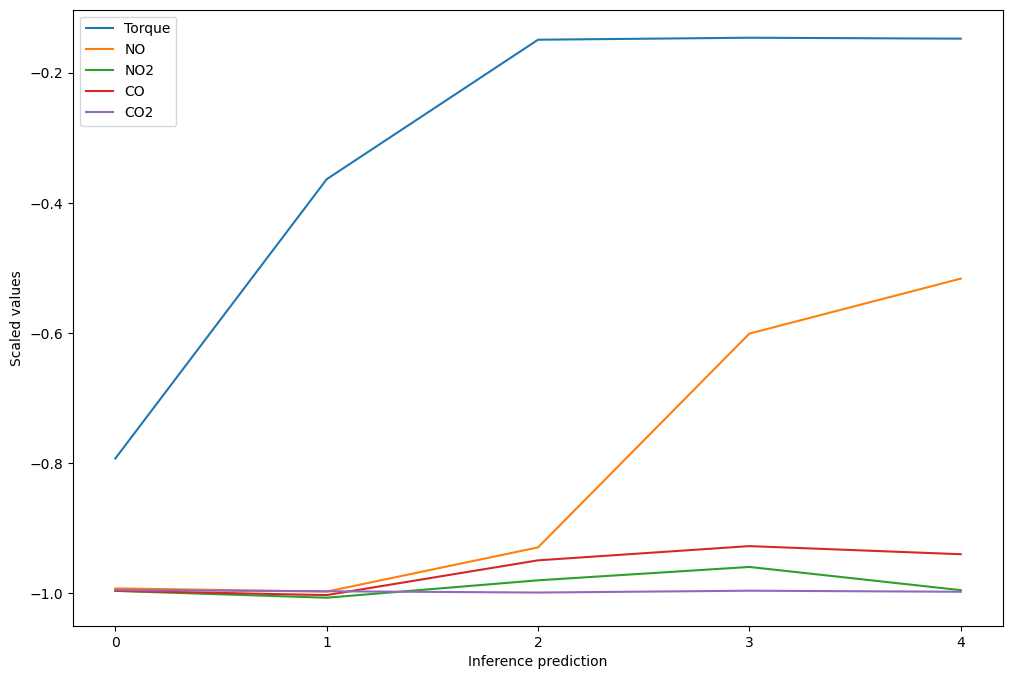

In [17]:
plot_data = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data.shape

labels = ['Torque', 'NO', 'NO2', 'CO', 'CO2']

_, ax = plt.subplots(figsize=(12,8))
for var in range(plot_vars):
    ax.plot(plot_data[:,var], label=labels[var])

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Scaled values')
ax.set_xlabel('Inference prediction')
ax.legend()

plt.show()

## ICE preformance time

In [18]:
%%timeit
ICE([x_scaled, y_scaled_ini])

26.2 µs ± 72.3 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Post-process

In [19]:
y_pred_list = []

for pred in range(preds):
    y_pred = ICEscaler_inv_out.transform(y_predict_scaled_list[pred].reshape(1, -1))
    y_pred_list.append(y_pred[0][0])

plot_data = np.array(y_pred_list)

### See results

In [20]:
y_pred = pd.DataFrame(data=plot_data, columns=labels)
y_pred

,Torque,NO,NO2,CO,CO2
0,-30.663227,0.001071,0.000008,0.000536,0.002289
1,91.710663,0.000352,-0.000015,-0.000426,0.001410
2,152.842926,0.010206,0.000043,0.007306,0.000470
3,153.717773,0.057880,0.000087,0.010468,0.001823
4,153.308853,0.070137,0.000010,0.008666,0.001042


#### Basic statistics

In [21]:
y_pred.describe().loc[['mean', 'std']]

,Torque,NO,NO2,CO,CO2
mean,104.183395,0.027929,0.000026,0.005310,0.001407
std,79.959198,0.033446,0.000040,0.004938,0.000700


**IMPORTANTE:**

Se puede observar como la primera predicción del torque produce un resultado negativo --> `-30.66 Nm`


### Plot results

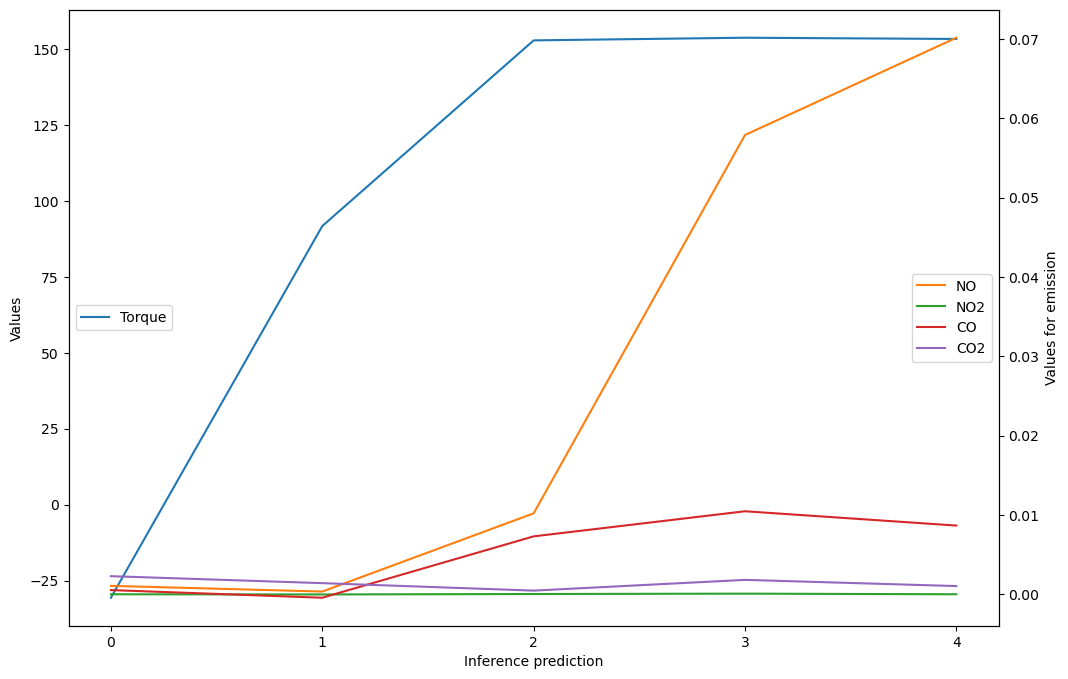

In [22]:
_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for emission')
ax2.legend(loc='center right')

plt.show()

## Repeat process for PG

### Model reset

In [23]:
PG.reset_states()

### Prepare input vector

Al igual que para el modelo ICE, se selecciona la primera fila del fichero seleccionado

In [24]:
x = PGinput.iloc[:1].copy()

#### Removing NaN value

In [25]:
x.iloc[:,2] = y_pred['Torque'].iloc[-1]
x = x.to_numpy()
x = x.astype('float32')

#### Scalling the input vector 

In [26]:
x_scaled = PGscaler_in.transform(x)
x_scaled = np.reshape(x_scaled, (1,1,4))

#### Preparing initial auxiliar vector

De nuevo, se toman los valores definidos por defecto en los ficheros `main.ipynb` y `transition_function_model.py`

In [27]:
SOC_ini = 0.7
velocity_ini = 0

y_ini = np.array([[velocity_ini, SOC_ini]], dtype='float32')
y_scaled_ini = PGscaler_out.transform(y_ini)[0].reshape((1,1,2))

### PG model prediction behaviour

Se ha evidenciado un comportamiento simuilar al modelo ICE pero con variaciones mucho más pequeñas que las observadas para ICE

In [28]:
y_predict_scaled_list = []

#### - 1st prediction call

In [29]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19865346,  0.40247518]]], dtype=float32)]

#### - 2nd prediction call

In [30]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.20063494,  0.40876144]]], dtype=float32)]

#### - 3rd prediction call

In [31]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.18923528,  0.40330288]]], dtype=float32)]

#### - 4th prediction call

In [32]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19683795,  0.40699983]]], dtype=float32)]

#### - 5th prediction call

In [33]:
y_predict_scaled = PG([x_scaled, y_scaled_ini])
y_predict_scaled_list.append(y_predict_scaled[0][0][0])
y_predict_scaled

[array([[[-0.19293256,  0.4072388 ]]], dtype=float32)]

Por favor notar como los valores del conjunto de ventores de entrada **NO se modifican** entre llamadas. Es decir, para el msimo conjunto de vectores de entrada, se obtienen diferentes valores de predicción.

### Plotting scaled results

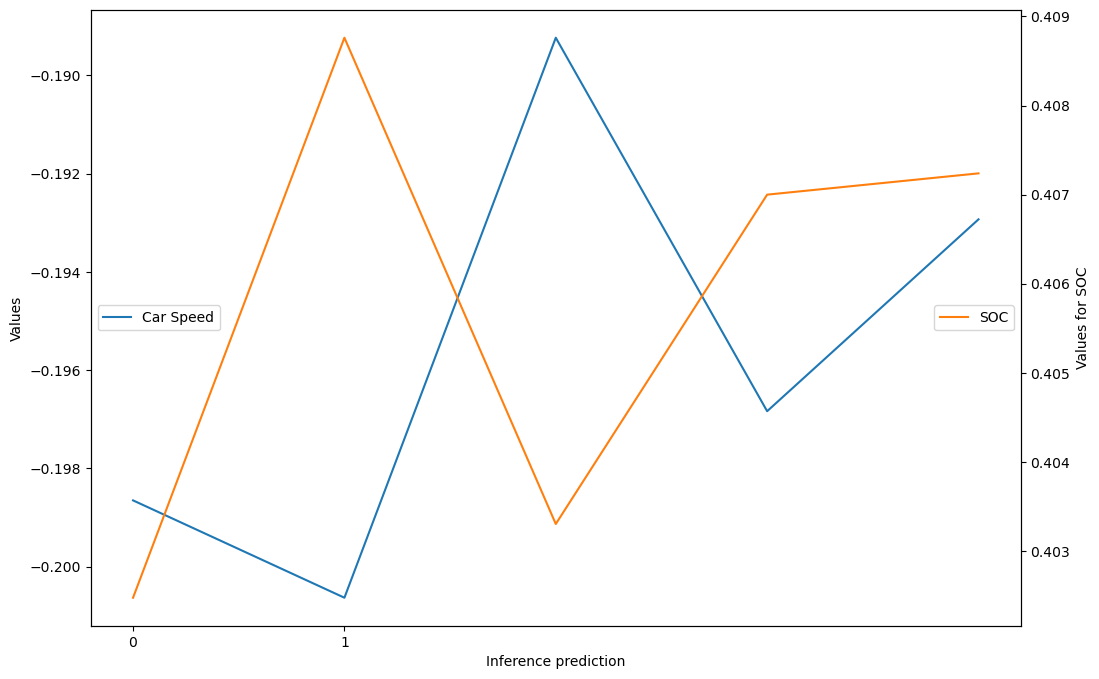

In [34]:
plot_data = np.array(y_predict_scaled_list)
preds, plot_vars = plot_data.shape

labels = ['Car Speed', 'SOC']

_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for SOC')
ax2.legend(loc='center right')

plt.show()

## PG preformance time

In [35]:
%%timeit
PG([x_scaled, y_scaled_ini])

41.3 µs ± 344 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


## Post-process

In [36]:
y_pred_list = []

for pred in range(preds):
    y_pred = PGscaler_inv_out.transform(y_predict_scaled_list[pred].reshape(1, -1))
    y_pred_list.append(y_pred[0][0])

plot_data = np.array(y_pred_list)

### See results

In [37]:
y_pred = pd.DataFrame(data=plot_data, columns=labels)
y_pred

,Car Speed,SOC
0,0.934679,0.701024
1,0.605810,0.704167
2,2.497827,0.701438
3,1.236002,0.703286
4,1.884184,0.703405


#### Basic statistics

In [38]:
y_pred.describe().loc[['mean', 'std']]

,Car Speed,SOC
mean,1.431700,0.702664
std,0.759735,0.001359


**Importante:**

Observar el elevado valor de desviación standard de la velocidad predicha para el mismo par de vectores de entrada

### Plot results

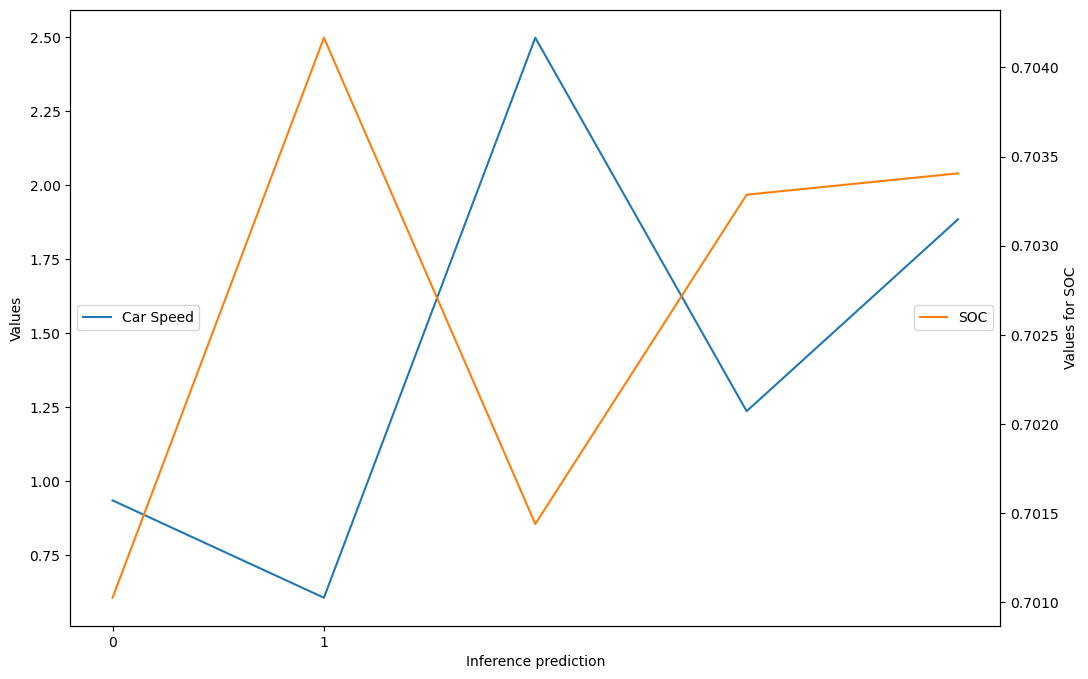

In [39]:
_, ax = plt.subplots(figsize=(12,8))
ax2 = ax.twinx()

for var in range(plot_vars):
    if var == 0:
        ax.plot(plot_data[:,var], label=labels[var], c=f'C{var}')
    else:
        ax2.plot(plot_data[:,var], label=labels[var], c=f'C{var}')

ax.set_xticks(range(plot_vars))

ax.set_ylabel('Values')
ax.set_xlabel('Inference prediction')
ax.legend(loc='center left')

ax2.set_ylabel('Values for SOC')
ax2.legend(loc='center right')

plt.show()